## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [1]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
! pip install ucimlrepo

   ---------------------------------------- 0.0/137.0 kB ? eta -:--:--
   -- ------------------------------------- 10.2/137.0 kB ? eta -:--:--
   -------- ------------------------------ 30.7/137.0 kB 435.7 kB/s eta 0:00:01
   -------- ------------------------------ 30.7/137.0 kB 435.7 kB/s eta 0:00:01
   ----------- --------------------------- 41.0/137.0 kB 217.9 kB/s eta 0:00:01
   -------------------- ------------------ 71.7/137.0 kB 326.8 kB/s eta 0:00:01
   ---------------------------- --------- 102.4/137.0 kB 392.2 kB/s eta 0:00:01
   ---------------------------------- --- 122.9/137.0 kB 450.6 kB/s eta 0:00:01
   -------------------------------------- 137.0/137.0 kB 404.9 kB/s eta 0:00:00
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.9 MB 2.0 MB/s eta 0:00:05
    --------------------------------------- 0.2/9.9 MB 2.1 MB/s eta 0:00:05
    --------------------------------------- 0.2/9.9 MB 2.1 MB/s eta 0:00:05



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), str(2)
memory usage: 48.6 KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192    4.559477   


### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

In [4]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     -------------- ----------------------- 30.7/80.3 kB 163.8 kB/s eta 0:00:01
     -------------- ----------------------- 30.7/80.3 kB 163.8 kB/s eta 0:00:01
     ------------------- ------------------ 41.0/80.3 kB 140.3 kB/s eta 0:00:01
     ----------------------------- -------- 61.4/80.3 kB 172.4 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 203.6 kB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/131.7 kB ? eta -:--:--
     ----------- ------------------------- 41.0/131.7 kB 991.0 kB/s eta 0:00:01
     ----------------------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
df = pd.read_csv('forestfires.csv')

print(df.head())
print(df.info())
print(df.describe())






   X  Y month  day  FFMC   DMC     DC  ISI  temp  RH  wind  rain  area
0  7  5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0   0.0
1  7  4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0   0.0
2  7  4   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0   0.0
3  8  6   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2   0.0
4  8  6   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0   0.0
<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64

In [17]:
months_mapping = {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6, 
                  'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}

df['month_num'] = df['month'].map(months_mapping)

In [18]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

correlation_matrix = numeric_df.corr()

print(correlation_matrix)

                  X         Y      FFMC       DMC        DC       ISI  \
X          1.000000  0.539548 -0.021039 -0.048384 -0.085916  0.006210   
Y          0.539548  1.000000 -0.046308  0.007782 -0.101178 -0.024488   
FFMC      -0.021039 -0.046308  1.000000  0.382619  0.330512  0.531805   
DMC       -0.048384  0.007782  0.382619  1.000000  0.682192  0.305128   
DC        -0.085916 -0.101178  0.330512  0.682192  1.000000  0.229154   
ISI        0.006210 -0.024488  0.531805  0.305128  0.229154  1.000000   
temp      -0.051258 -0.024103  0.431532  0.469594  0.496208  0.394287   
RH         0.085223  0.062221 -0.300995  0.073795 -0.039192 -0.132517   
wind       0.018798 -0.020341 -0.028485 -0.105342 -0.203466  0.106826   
rain       0.065387  0.033234  0.056702  0.074790  0.035861  0.067668   
area       0.063385  0.044873  0.040122  0.072994  0.049383  0.008258   
month_num -0.065003 -0.066292  0.291477  0.466645  0.868698  0.186597   

               temp        RH      wind      rain 

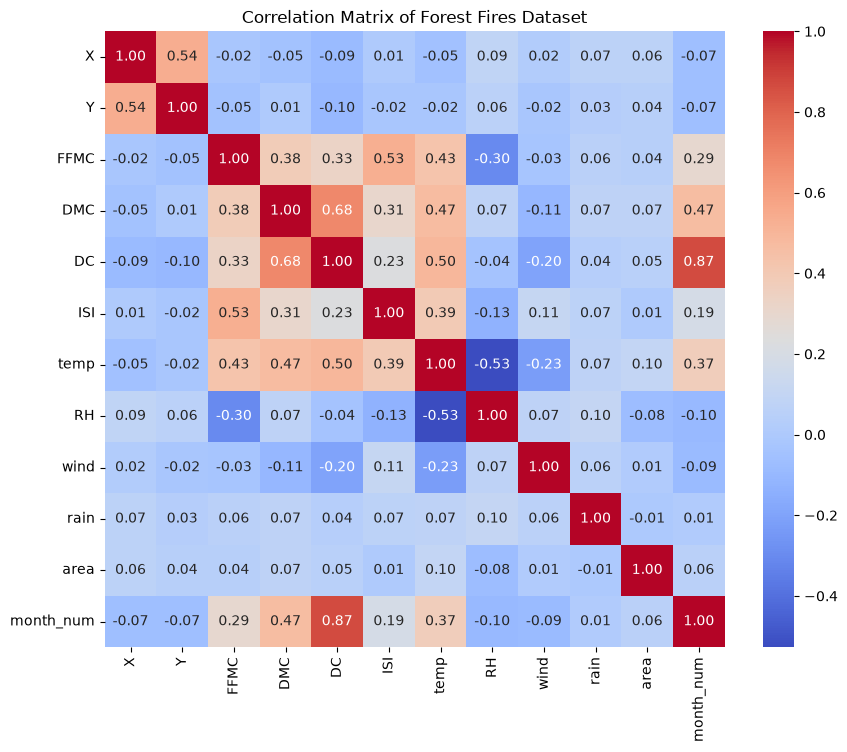

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Forest Fires Dataset')
plt.show()

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [21]:
!pip install statsmodels

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------ ------------------------- 20.5/61.0 kB 217.9 kB/s eta 0:00:01
     ------------------- ------------------ 30.7/61.0 kB 187.9 kB/s eta 0:00:01
     ------------------- ------------------ 30.7/61.0 kB 187.9 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/61.0 kB 164.3 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 216.7 kB/s eta 0:00:00
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB 960.0 kB/s eta 0:00:12
   ---------------------------------------- 0.1/11.4 MB 1.0 MB/s eta 0:00:11
   ---------------------------------------- 0.1/11.4 MB 1.0 MB/s eta 0:00:11
    --------------------------------------- 0.1/11.4 MB 708.1 kB/s eta 0:00:16
    ----


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import statsmodels.api as sm

X = df[['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']]
y = df['area']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.119
Date:                Sat, 26 Sep 2026   Prob (F-statistic):              0.345
Time:                        17:00:29   Log-Likelihood:                -2874.8
No. Observations:                 517   AIC:                             5772.
Df Residuals:                     506   BIC:                             5818.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.3693     63.019     -0.101      0.9

In [26]:
X['temp_squared'] = df['temp'] ** 2
X['rain_squared'] = df['rain'] ** 2

model_nonlinear = sm.OLS(y, X).fit()
print(model_nonlinear.summary())


                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.011
Date:                Sat, 26 Sep 2026   Prob (F-statistic):              0.437
Time:                        17:02:09   Log-Likelihood:                -2874.3
No. Observations:                 517   AIC:                             5775.
Df Residuals:                     504   BIC:                             5830.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -2.8403     64.091     -0.044   

In [28]:
X['temp_RH_interaction'] = df['temp'] * df['RH']

# Refit the model
model_interaction = sm.OLS(y, X).fit()
print(model_interaction.summary())

                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9661
Date:                Sat, 26 Sep 2026   Prob (F-statistic):              0.484
Time:                        17:06:19   Log-Likelihood:                -2874.1
No. Observations:                 517   AIC:                             5776.
Df Residuals:                     503   BIC:                             5836.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 -35.1247    

In [33]:
#Convert categorical variables (month, day) into dummy variables using pd.get_dummies.

# Convert categorical variables into dummy/indicator variables
df_dummies = pd.get_dummies(df[['month', 'day']], drop_first=True)
# Remove any existing dummy columns so the cell can be rerun safely
X = X.drop(columns=df_dummies.columns, errors='ignore')

# Add the categorical dummy variables
X = X.join(df_dummies.astype(float))

# Refit the model
model_with_dummies = sm.OLS(y, X).fit()
print(model_with_dummies.summary())

                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                    0.8028
Date:                Sat, 26 Sep 2026   Prob (F-statistic):              0.764
Time:                        17:12:01   Log-Likelihood:                -2867.9
No. Observations:                 517   AIC:                             5798.
Df Residuals:                     486   BIC:                             5930.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.3444    

In [36]:
import numpy as np

df['log_area'] = np.log1p(df['area'])  # log1p handles log(0)
y = df['log_area']

# Refit the model
model_transformed = sm.OLS(y, X).fit()
print(model_transformed.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     1.628
Date:                Sat, 26 Sep 2026   Prob (F-statistic):             0.0205
Time:                        17:16:26   Log-Likelihood:                -881.72
No. Observations:                 517   AIC:                             1825.
Df Residuals:                     486   BIC:                             1957.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.6995    

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

In [38]:
{
    'Baseline': model,
    'Nonlinear': model_nonlinear,
    'Interaction': model_interaction,
    'With Dummies': model_with_dummies,
    'Transformed': model_transformed
}

comparison = []

models = {
    'Baseline': model,
    'Nonlinear': model_nonlinear,
    'Interaction': model_interaction,
    'With Dummies': model_with_dummies,
    'Transformed': model_transformed
}

comparison = []

for name, mdl in models.items():
    comparison.append({
        'Model': name,
        'R2': mdl.rsquared,
        'Adj. R2': mdl.rsquared_adj,
        'AIC': mdl.aic,
        'BIC': mdl.bic
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df)

comparison_df = pd.DataFrame(comparison)
print(comparison_df)

          Model        R2   Adj. R2          AIC          BIC
0      Baseline  0.021640  0.002305  5771.580275  5818.308747
1     Nonlinear  0.023506  0.000257  5774.592992  5829.817549
2   Interaction  0.024360 -0.000856  5776.141006  5835.613606
3  With Dummies  0.047217 -0.011597  5797.884697  5929.574026
4   Transformed  0.091318  0.035226  1825.430093  1957.119422
          Model        R2   Adj. R2          AIC          BIC
0      Baseline  0.021640  0.002305  5771.580275  5818.308747
1     Nonlinear  0.023506  0.000257  5774.592992  5829.817549
2   Interaction  0.024360 -0.000856  5776.141006  5835.613606
3  With Dummies  0.047217 -0.011597  5797.884697  5929.574026
4   Transformed  0.091318  0.035226  1825.430093  1957.119422


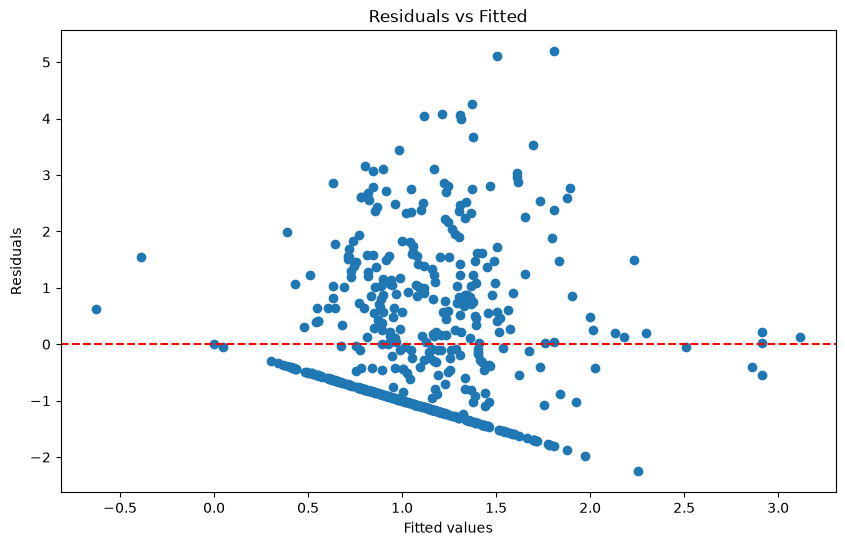

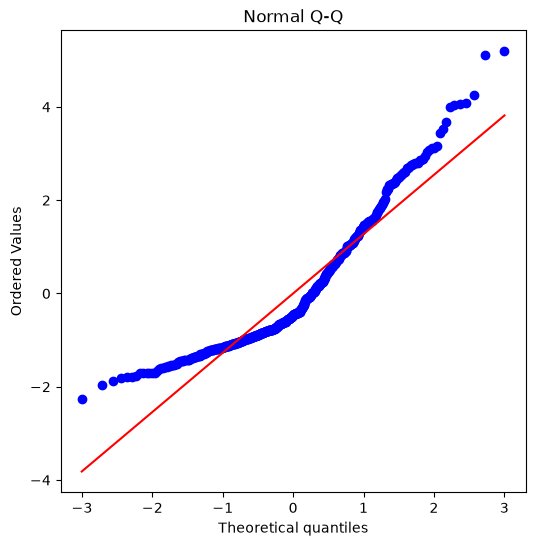

In [39]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# For residuals from the selected model (e.g., model_transformed)
residuals = model_transformed.resid

# Residual plot
plt.figure(figsize=(10, 6))
plt.scatter(model_transformed.fittedvalues, residuals)
plt.axhline(y=0, linestyle='--', color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# Q-Q Plot
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Normal Q-Q")
plt.show()

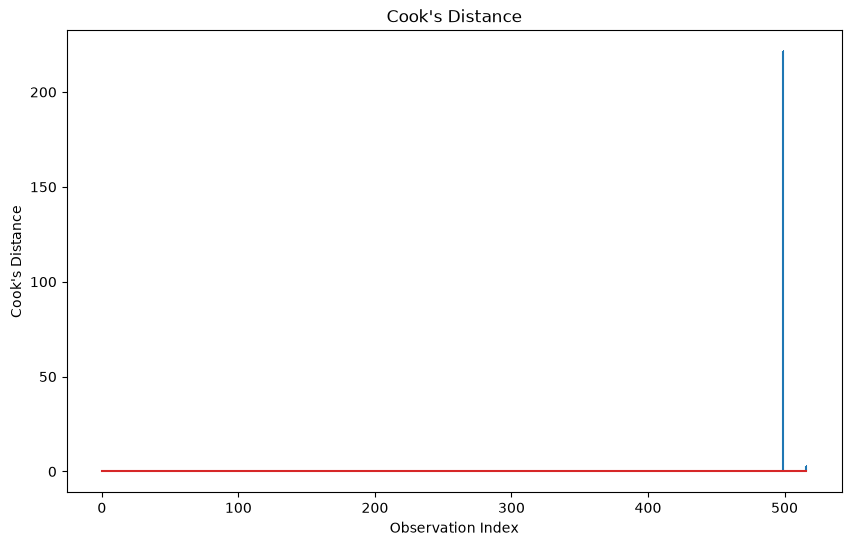

Influential Points: [104 210 211 223 226 235 236 237 238 293 304 377 379 395 415 420 445 469
 471 473 479 499 509 513 516]


In [40]:
# Calculate Cook's Distance
infl = model_transformed.get_influence()
cooks_d = infl.cooks_distance[0]

# Plot Cook's Distance
plt.figure(figsize=(10, 6))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.title("Cook's Distance")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.show()

# Highlight influential observations
influential_points = np.where(cooks_d > 4/(len(df)-len(X.columns)-1))
print("Influential Points:", influential_points[0])

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [44]:
%pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [46]:
%pip install scikit-learn
r


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB 435.7 kB/s eta 0:00:20
   ---------------------------------------- 0.0/8.3 MB 326.8 kB/s eta 0:00:26
   ---------------------------------------- 0.0/8.3 MB 326.8 kB/s eta 0:00:26
   ---------------------------------------- 0.1/8.3 MB 252.2 kB/s eta 0:00:33
   ---------------------------------------- 0.1/8.3 MB 305.0 kB/s eta 0:00:28
   ---------------------------------------- 0.1/8.3 MB 308.0 kB/s eta 0:00:27
    --------------------------------------- 0.1/8.3 MB 327.2 kB/s eta 0:00:26
    --------------------------------------- 0.1/8.3 MB 288.1 kB/s eta 0:00:29
    --------------------------------------- 0.2/8.3 MB 374.1 kB/s eta 0:00:22
   - ------------------------

In [47]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error

In [48]:
X = df[['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']]
y = df['area']

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_train_pred = ridge_model.predict(X_train)
ridge_test_pred = ridge_model.predict(X_test)

In [52]:
# Lasso Regression
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)
lasso_train_pred = lasso_model.predict(X_train)
lasso_test_pred = lasso_model.predict(X_test)

In [53]:
# Coefficients
ridge_coefficients = ridge_model.coef_
lasso_coefficients = lasso_model.coef_

print("Ridge Coefficients:", ridge_coefficients)
print("Lasso Coefficients:", lasso_coefficients)

Ridge Coefficients: [ 2.14064737  0.06169558 -0.09983549  0.11072622 -0.01037838 -0.29760548
  0.4028437  -0.1914664   0.84225447 -2.46342287]
Lasso Coefficients: [ 1.95419256  0.         -0.09836923  0.11188081 -0.01060529 -0.14903591
  0.25798365 -0.20663604  0.38101787 -0.        ]


In [54]:
# Calculate Mean Squared Error for both models
ridge_mse_train = mean_squared_error(y_train, ridge_train_pred)
ridge_mse_test = mean_squared_error(y_test, ridge_test_pred)
lasso_mse_train = mean_squared_error(y_train, lasso_train_pred)
lasso_mse_test = mean_squared_error(y_test, lasso_test_pred)

print("Ridge Train MSE:", ridge_mse_train)
print("Ridge Test MSE:", ridge_mse_test)
print("Lasso Train MSE:", lasso_mse_train)
print("Lasso Test MSE:", lasso_mse_test)

Ridge Train MSE: 2008.3827167300242
Ridge Test MSE: 11759.994711415928
Lasso Train MSE: 2009.9096717403336
Lasso Test MSE: 11779.349509233047


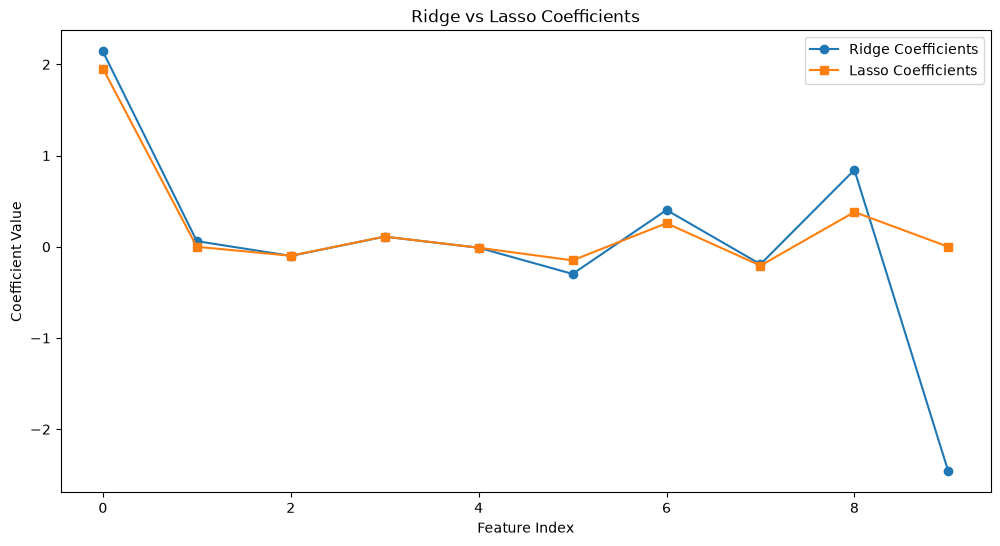

In [55]:
# Plot Ridge coefficients vs Lasso coefficients
plt.figure(figsize=(12, 6))
plt.plot(range(len(ridge_coefficients)), ridge_coefficients, 'o-', label="Ridge Coefficients")
plt.plot(range(len(lasso_coefficients)), lasso_coefficients, 's-', label="Lasso Coefficients")
plt.title("Ridge vs Lasso Coefficients")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.legend()
plt.show()

### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [56]:
# Compute the median of y
threshold = df['area'].median()

# Create a binary target variable
df['binary_target'] = np.where(df['area'] > threshold, 1, 0)

# Check the distribution of the new target variable
print(df['binary_target'].value_counts())

binary_target
0    259
1    258
Name: count, dtype: int64


In [57]:
X = df[['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']]
y = df['binary_target']

In [59]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print(X_scaled_df.describe())

                  X             Y          FFMC           DMC            DC  \
count  5.170000e+02  5.170000e+02  5.170000e+02  5.170000e+02  5.170000e+02   
mean   2.113074e-16  2.611279e-16 -1.752306e-15 -2.748715e-17  6.871787e-17   
std    1.000969e+00  1.000969e+00  1.000969e+00  1.000969e+00  1.000969e+00   
min   -1.587360e+00 -1.871724e+00 -1.304582e+01 -1.715608e+00 -2.179108e+00   
25%   -7.221360e-01 -2.440010e-01 -8.063453e-02 -6.606652e-01 -4.448281e-01   
50%   -2.895238e-01 -2.440010e-01  1.732292e-01 -4.020255e-02  4.691190e-01   
75%    1.008313e+00  5.698604e-01  4.089598e-01  4.927389e-01  6.696628e-01   
max    1.873537e+00  3.825306e+00  1.007353e+00  2.819865e+00  1.261610e+00   

                ISI          temp            RH          wind          rain  
count  5.170000e+02  5.170000e+02  5.170000e+02  5.170000e+02  5.170000e+02  
mean   1.030768e-17  2.542561e-16  2.198972e-16 -4.191790e-16 -6.871787e-18  
std    1.000969e+00  1.000969e+00  1.000969e+00  1.000

### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

# Initialize the logistic regression model
log_reg = LogisticRegression()

# Train the model on the training data
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [61]:
# Display coefficients and intercept
coefficients = pd.Series(log_reg.coef_[0], index=X_scaled_df.columns)
intercept = log_reg.intercept_[0]

print("Logistic Regression Coefficients:")
print(coefficients)
print("\nIntercept:", intercept)

Logistic Regression Coefficients:
X       0.096887
Y       0.084400
FFMC    0.254312
DMC    -0.005715
DC      0.143621
ISI    -0.234127
temp    0.053519
RH     -0.020198
wind    0.193317
rain    0.037752
dtype: float64

Intercept: -0.007647134588929799


In [62]:
# Predict probabilities
y_prob = log_reg.predict_proba(X_test)[:, 1]

# Predict binary outcomes
y_pred = log_reg.predict(X_test)

# Display some predicted probabilities and binary outcomes
print("\nPredicted probabilities:", y_prob[:5])
print("Predicted binary outcomes:", y_pred[:5])


Predicted probabilities: [0.46035369 0.59329312 0.56449008 0.49673831 0.4397957 ]
Predicted binary outcomes: [0 1 1 0 0]


In [63]:
#Evaluate Model Performance
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display the performance metrics
print("\nPerformance Metrics:")
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)


Performance Metrics:
Accuracy: 0.5480769230769231
Confusion Matrix:
 [[30 23]
 [24 27]]
Precision: 0.54
Recall: 0.5294117647058824
F1-Score: 0.5346534653465347


* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

### Step 8: Check assumptions

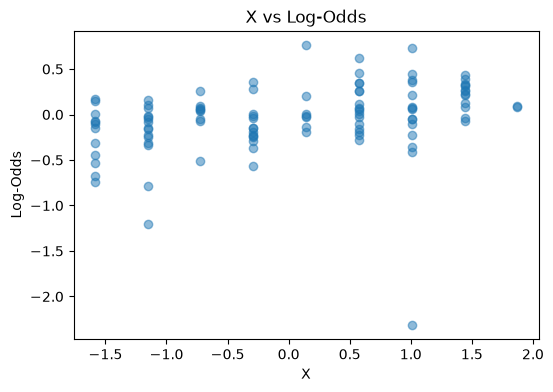

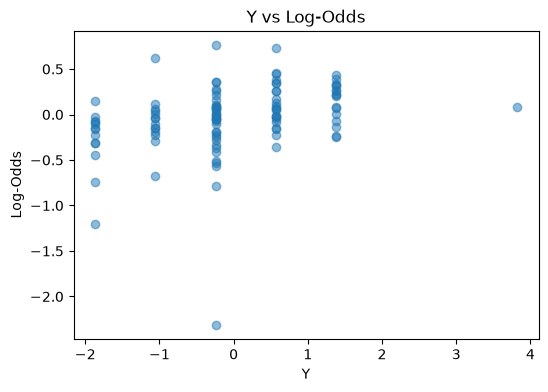

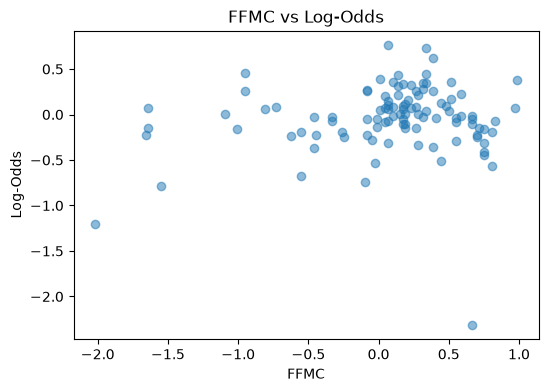

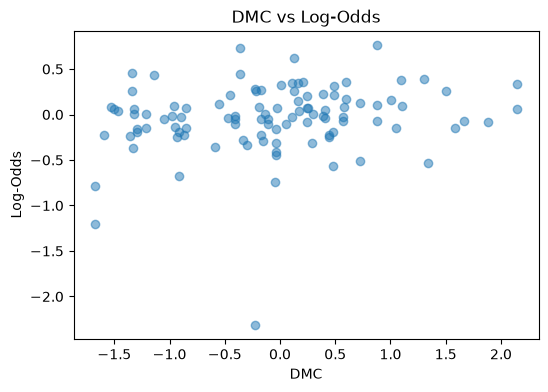

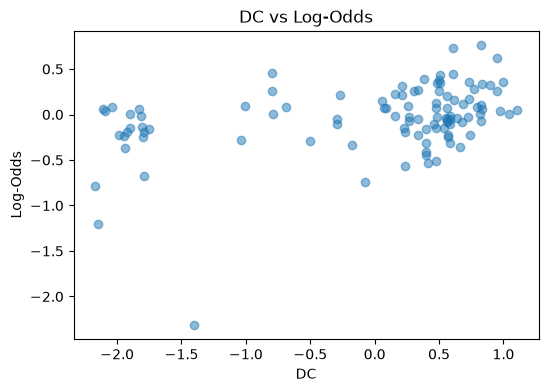

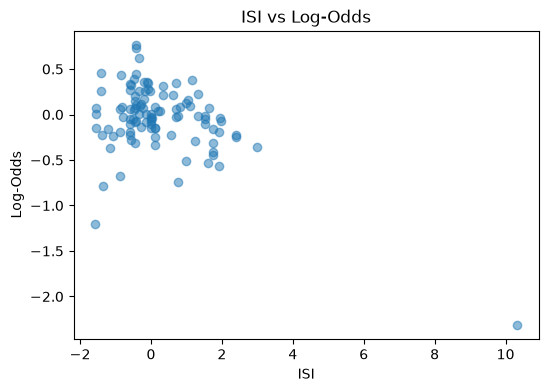

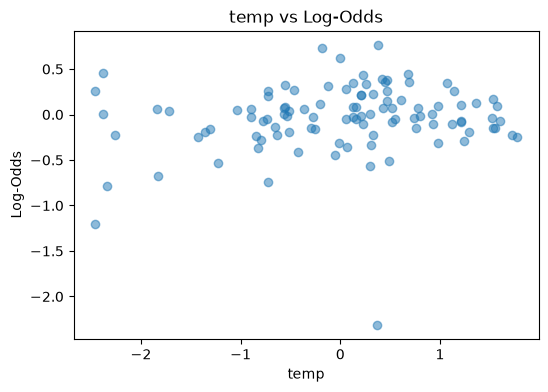

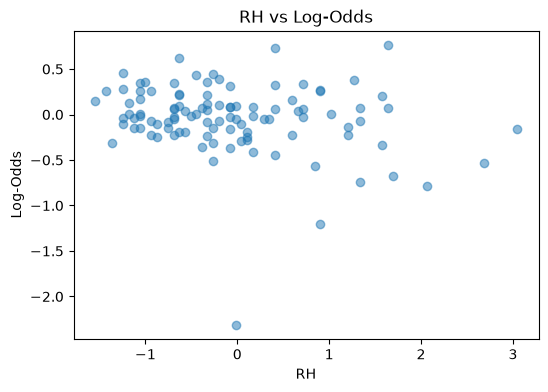

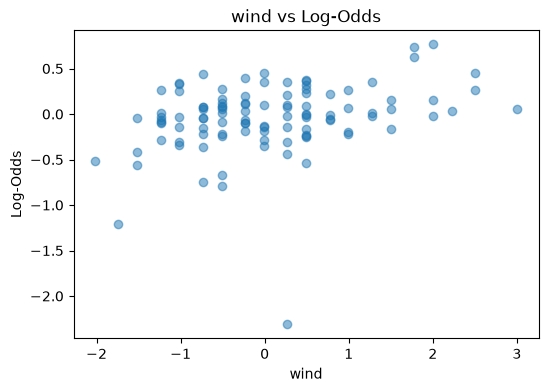

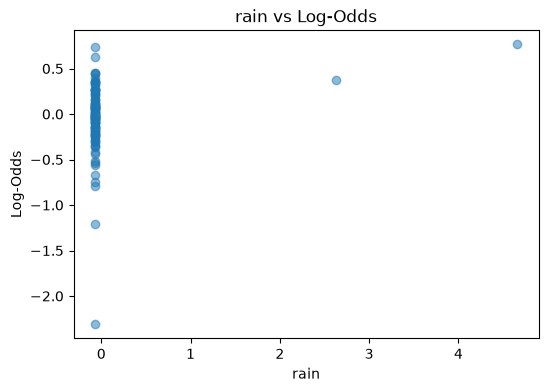

In [65]:
log_odds = np.log(y_prob / (1 - y_prob))

# Plot each predictor against the log-odds
for column in X_scaled_df.columns:
    plt.figure(figsize=(6, 4))
    plt.scatter(X_test[column], log_odds, alpha=0.5)
    plt.title(f'{column} vs Log-Odds')
    plt.xlabel(column)
    plt.ylabel('Log-Odds')
    plt.show()

In [67]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_scaled_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled_df.values, i) for i in range(X_scaled_df.shape[1])]

print(vif_data)


  Feature       VIF
0       X  1.433429
1       Y  1.445610
2    FFMC  1.698060
3     DMC  2.361567
4      DC  2.125930
5     ISI  1.579370
6    temp  2.666717
7      RH  1.913799
8    wind  1.142779
9    rain  1.047796


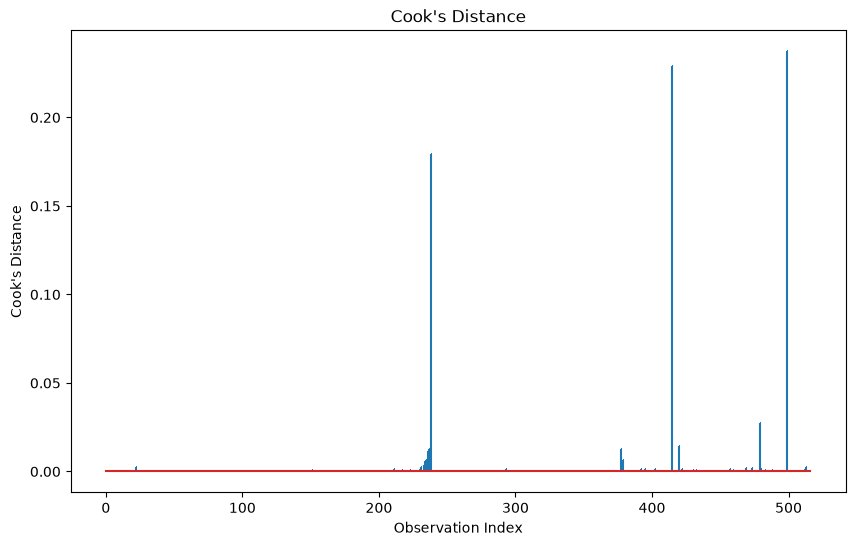

Influential Points: [238 415 499]


In [68]:
from statsmodels.stats.outliers_influence import OLSInfluence

# Fit an OLS to extract influence measures
model_influence = OLSInfluence(model)
cooks_d = model_influence.cooks_distance

# Plot
plt.figure(figsize=(10, 6))
plt.stem(np.arange(len(cooks_d[0])), cooks_d[0], markerfmt=",")
plt.title("Cook's Distance")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.show()

# Identify influential observations
influential_points = np.where(cooks_d[0] > 4 / (X_test.shape[0] - len(X_test.columns) - 1))
print("Influential Points:", influential_points[0])

### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

[Type your findings here.]